In [1]:
import pandas as pd
import kaggle
kaggle.api.authenticate()
print("Authenticated!")

Authenticated!


## Step 1 - Load & Explore

Download the dataset from Kaggle, check shape, columns, missing values and rating distribution.

In [2]:
kaggle.api.dataset_download_files("prakharrathi25/google-play-store-reviews", path='./data', unzip=True)

Dataset URL: https://www.kaggle.com/datasets/prakharrathi25/google-play-store-reviews


In [3]:
import os
os.listdir('./data')

['reviews.csv']

In [4]:
df = pd.read_csv('./data/reviews.csv')
print(df.shape)
print(df.head())

(12495, 12)
                                            reviewId  \
0  gp:AOqpTOEhZuqSqqWnaKRgv-9ABYdajFUB0WugPGh-SG-...   
1  gp:AOqpTOH0WP4IQKBZ2LrdNmFy_YmpPCVrV3diEU9KGm3...   
2  gp:AOqpTOEMCkJB8Iq1p-r9dPwnSYadA5BkPWTf32Z1azu...   
3  gp:AOqpTOGFrUWuKGycpje8kszj3uwHN6tU_fd4gLVFy9z...   
4  gp:AOqpTOHls7DW8wmDFzTkHwxuqFkdNQtKHmO6Pt9jhZE...   

                           userName  \
0                          Eric Tie   
1                        john alpha   
2                       Sudhakar .S   
3  SKGflorida@bellsouth.net DAVID S   
4                     Louann Stoker   

                                           userImage  \
0  https://play-lh.googleusercontent.com/a-/AOh14...   
1  https://play-lh.googleusercontent.com/a-/AOh14...   
2  https://play-lh.googleusercontent.com/a-/AOh14...   
3  https://play-lh.googleusercontent.com/-75aK0WF...   
4  https://play-lh.googleusercontent.com/-pBcY_Z-...   

                                             content  score  thumbsUpCount  \
0

In [5]:
df['content'].isna().sum()

np.int64(0)

In [6]:
print(df['score'].value_counts())

score
5    2879
4    2775
1    2506
2    2344
3    1991
Name: count, dtype: int64


In [7]:
df['score'].isna().sum()

np.int64(0)

In [8]:
def get_sentiment(score):
    if score >=4:
        return 'positive'
    elif score >=3:
        return 'neutral'
    else:
        return 'negative'
    
df['sentiment'] = df['score'].apply(get_sentiment)

print(df['sentiment'].value_counts())


sentiment
positive    5654
negative    4850
neutral     1991
Name: count, dtype: int64


# Step 2 — Text Cleaning

In [9]:
def clean_text(text):
    text = text.lower()
    text = ''.join(c for c in text if c != '<' and c != '>')  # basic HTML removal
    text = ''.join(c for c in text if c.isalnum() or c.isspace())
    text = ' '.join(text.split())
    return text

df['clean_text'] = df['content'].apply(clean_text)

print(df['clean_text'].head(3))

0                        i cannot open the app anymore
1    i have been begging for a refund from this app...
2    very costly for the premium version approx ind...
Name: clean_text, dtype: object


Tokenization

In [10]:
import nltk

nltk.download('punkt_tab')

from nltk.tokenize import word_tokenize

df['tokens'] = df['clean_text'].apply(word_tokenize)

print(df['tokens'].head())

[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


0               [i, can, not, open, the, app, anymore]
1    [i, have, been, begging, for, a, refund, from,...
2    [very, costly, for, the, premium, version, app...
3    [used, to, keep, me, organized, but, all, the,...
4                             [dan, birthday, oct, 28]
Name: tokens, dtype: object


Stopword removal

In [11]:
nltk.download('stopwords')

from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    clean = []
    for word in tokens:
        if word not in stop_words:
            clean.append(word)
    return clean

df['tokens_clean'] = df['tokens'].apply(remove_stopwords)

print(df['tokens_clean'][0])

['open', 'app', 'anymore']


[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Lemmatization

In [12]:
nltk.download('wordnet')

from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    lemmas = []
    for word in tokens:
        lemma = lemmatizer.lemmatize(word, pos='v')  # treat as verb
        lemmas.append(lemma)
    return lemmas

df['lemmas'] = df['tokens_clean'].apply(lemmatize_tokens)

print("Tokens: ", df['tokens_clean'][0][:10])
print("Lemmas: ", df['lemmas'][0][:10])

[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Tokens:  ['open', 'app', 'anymore']
Lemmas:  ['open', 'app', 'anymore']


In [13]:
def join_tokens(tokens):
    return ' '.join(tokens)

df['lemmas_str'] = df['lemmas'].apply(join_tokens)

# Step 3 - Vader for sentiment analysis

In [14]:
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

def sentiment_analysis(text):
    scores = sia.polarity_scores(text)
    return scores ['compound']

df['vader_score'] = df['clean_text'].apply(sentiment_analysis)

# Step 4 - Scores to labels

In [15]:
def score_to_labels(score):
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

df['vader_label'] = df['vader_score'].apply(score_to_labels)

Evaluate

In [16]:
from sklearn.metrics import classification_report, accuracy_score

print(accuracy_score(df['sentiment'], df['vader_label']))
print(classification_report(df['sentiment'], df['vader_label']))

0.5758303321328532
              precision    recall  f1-score   support

    negative       0.74      0.42      0.54      4850
     neutral       0.16      0.16      0.16      1991
    positive       0.62      0.85      0.72      5654

    accuracy                           0.58     12495
   macro avg       0.51      0.48      0.47     12495
weighted avg       0.59      0.58      0.56     12495



## Step 5 - Logistic Regression with TF-IDF + Bigrams

Vectorize text using TF-IDF including bigrams (word pairs like "keeps crashing", "not good"), then train a Logistic Regression classifier.

Step 5 - Logistic regression

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

In [18]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

X = tfidf.fit_transform(df['lemmas_str'])

y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=33)

In [19]:
from sklearn.linear_model import LogisticRegression

lg = LogisticRegression(max_iter=1000, class_weight='balanced')

lg.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [20]:
y_pred = lg.predict(X_test)

print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.6578631452581032
              precision    recall  f1-score   support

    negative       0.70      0.72      0.71       981
     neutral       0.26      0.30      0.28       387
    positive       0.80      0.72      0.76      1131

    accuracy                           0.66      2499
   macro avg       0.58      0.58      0.58      2499
weighted avg       0.68      0.66      0.67      2499



## Step 6 - Topic Modelling with LDA

Discover hidden themes in the reviews using Latent Dirichlet Allocation. No labels needed - LDA finds patterns on its own.

### LDA Topics

7 topics discovered:
- Topic 1: General usage/habits
- Topic 2: Calendar & scheduling features
- Topic 3: Positive feedback
- Topic 4: Negative feedback & bugs
- Topic 5: UI & widget issues
- Topic 6: Pricing complaints
- Topic 7: Task management

LDA

In [21]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(max_features=5000)

X = cv.fit_transform(df['lemmas_str'])

In [22]:
from sklearn.decomposition import LatentDirichletAllocation

lda = LatentDirichletAllocation(n_components=7, random_state=33)

lda.fit(X)

LatentDirichletAllocation(n_components=7, random_state=33)

In [23]:
words = cv.get_feature_names_out()

for i, topic in enumerate(lda.components_):
    top_words = []
    for j in topic.argsort()[-10:][::-1]:
        top_words.append(words[j])
    print(f"Topic {i+1}: {', '.join(top_words)}")

Topic 1: app, use, work, get, time, im, really, like, habit, love
Topic 2: task, time, calendar, day, set, app, add, like, show, one
Topic 3: love, app, would, like, helpful, awesome, user, planner, great, note
Topic 4: app, dont, get, task, work, like, useful, notifications, would, really
Topic 5: app, widget, use, nice, easy, simple, please, open, work, phone
Topic 6: app, version, good, pay, premium, free, use, sync, pro, buy
Topic 7: app, list, task, great, use, help, best, need, keep, really


## Step 7 - Visualisations

Step 7 - visualisation

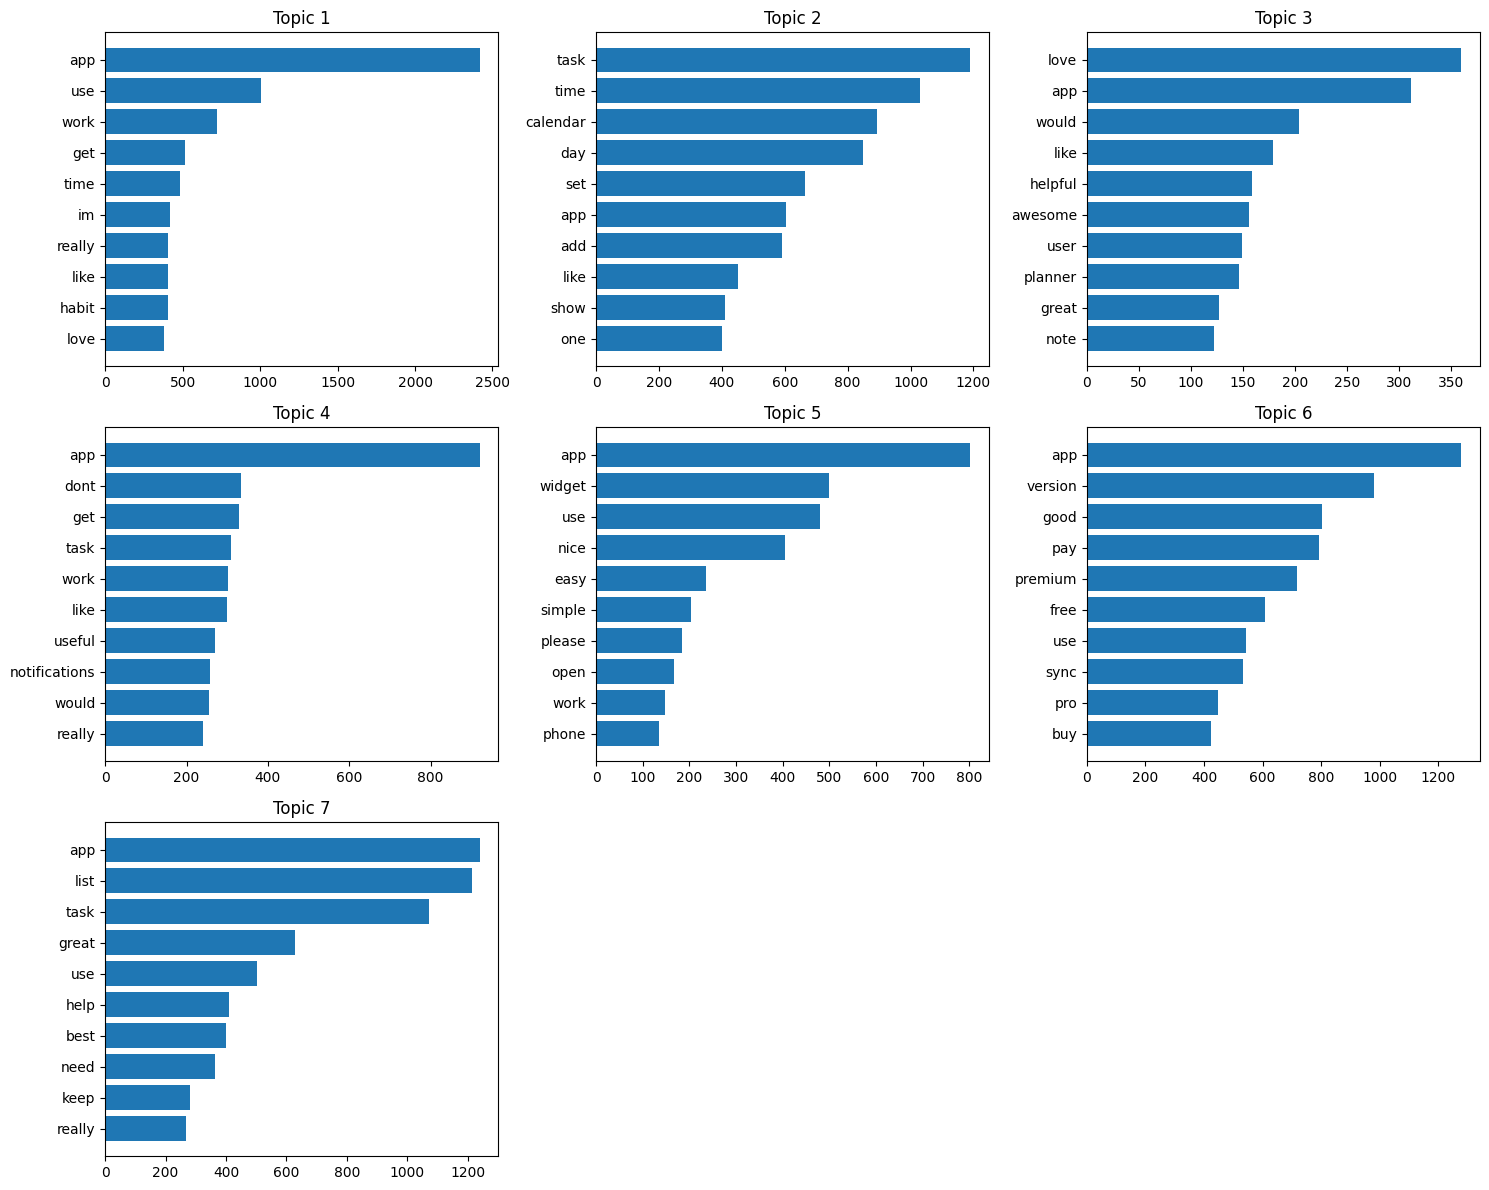

In [24]:
import matplotlib.pyplot as plt


fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, topic in enumerate(lda.components_):
    top_indices = topic.argsort()[-10:][::-1]
    top_words = [words[j] for j in top_indices]
    top_scores = [topic[j] for j in top_indices]
    
    axes[i].barh(top_words[::-1], top_scores[::-1])
    axes[i].set_title(f'Topic {i+1}')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
    
plt.tight_layout()
plt.show()

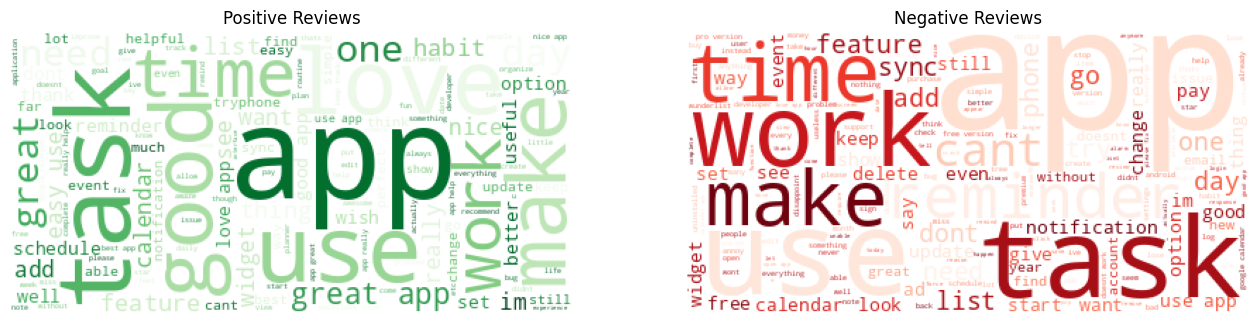

In [25]:
from wordcloud import WordCloud

# Separate positive and negative reviews
positive_text = ' '.join(df[df['sentiment'] == 'positive']['lemmas_str'])
negative_text = ' '.join(df[df['sentiment'] == 'negative']['lemmas_str'])

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

wordcloud_pos = WordCloud(background_color='white', colormap='Greens').generate(positive_text)
wordcloud_neg = WordCloud(background_color='white', colormap='Reds').generate(negative_text)

axes[0].imshow(wordcloud_pos)
axes[0].set_title('Positive Reviews')
axes[0].axis('off')

axes[1].imshow(wordcloud_neg)
axes[1].set_title('Negative Reviews')
axes[1].axis('off')

plt.show()

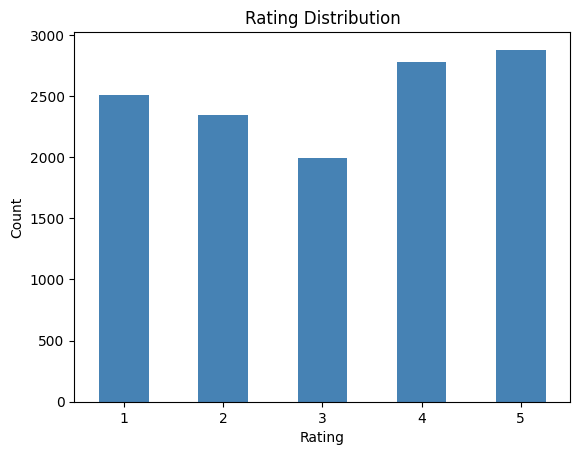

In [26]:
df["score"].value_counts().sort_index().plot(kind="bar", color="steelblue")
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

## Conclusion

In this project, I built a full NLP pipeline on 12,495 Google Play Store reviews.

**What I did:**
- Cleaned and preprocessed raw review text
- Tokenized, removed stopwords and lemmatized using NLTK
- Applied VADER sentiment analysis — achieved 58% accuracy with no training
- Trained a Logistic Regression classifier on TF-IDF features with bigrams — achieved 72% accuracy
- Used class balancing to improve detection of negative and neutral reviews
- Discovered 7 hidden topics using LDA (e.g. pricing complaints, calendar features, UI issues)

**Key findings:**
- VADER underperforms on app reviews  — short technical text like "keeps crashing" is harder for rule-based tools
- Bigrams significantly helped the classifier pick up on phrases like "not good" and "keeps crashing"
- Pricing (Topic 6) emerged as a major theme — users frequently complain about premium/paid features

**Next steps:**
- Try SVM or Random Forest for comparison
- Analyse sentiment by app category
- Fine-tune number of LDA topics